**ANN Backpropagation Algorithm**

Problem Statement

Consider the following Artificial Neural Network: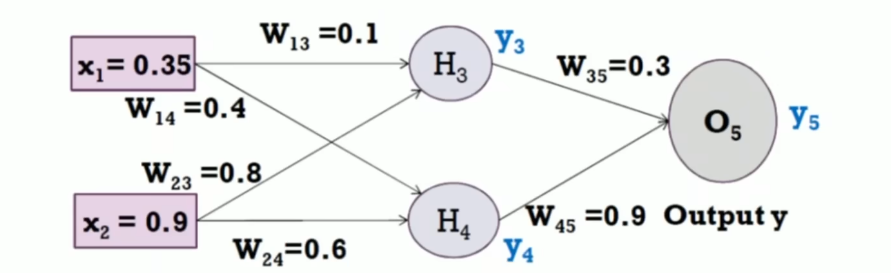

More specifically, the network has:

2 input neurons: \(x_1,x_2\)
2 hidden neurons: \(H_3,H_4\)
1 output neuron: \(O_5\)
Activation function: Sigmoid
Learning rate:
$$ \eta=1 $$
Input values
$$ x_1=0.35 $$ $$ x_2=0.90 $$
Initial weights
Weight	Value

\(w13)	0.1

(w23)	          0.8

\(w14)        	0.4

\(w24)        	0.6

\(w35)         	0.3

\(w45)	        0.9

Target output:

$$ \boxed{y_{target}=0.5} $$

The objective is to:

Perform one iteration of the Backpropagation algorithm, calculate the network output, calculate the error, calculate the delta values, and update all weights.

In [3]:
import numpy as np

#inputs
x1 = 0.35
x2 = 0.90
target = 0.5
eta = 1.0

#initial weights
w13 = 0.1
w23 = 0.8
w14 = 0.4
w24 = 0.6

w35 = 0.3
w45 = 0.9

#sigmoid function

def sigmoid(x):
 return 1/(1+np.exp(-x))

In [8]:
#forward bias
#hidden neuron H3

a1 = w13*x1 + w23*x2
y3=sigmoid(a1)
print("a1 =", a1)
print("y3 =", y3)

#hidden neuron H4
a2 = w14*x1 + w24*x2
y4 = sigmoid(a2)
print("a2 =",a2)
print("y4 =",y4)

#output neuron O5
a3 = w14*y3 + w24*y4
y5 = sigmoid(a3)
print("a3 =",a3)
print("y5 =",y5)

a1 = 0.7550000000000001
y3 = 0.6802671966986485
a2 = 0.68
y4 = 0.6637386974043528
a3 = 0.670350097122071
y5 = 0.6615815473725495


In [9]:
print("Error =", target-y5)

Error = -0.16158154737254948


In [10]:
#Backword pass
#output delta
delta5 = y5*(1-y5)*(target-y5)

delta3 = y3*(1-y3)*(w35*delta5)
delta4 = y4*(1-y4)*(w45*delta3)

print("delta5 =", delta5)
print("delta3 =", delta3)
print("delta4 =", delta4)

delta5 = -0.03617671942880966
delta3 = -0.002360571509071734
delta4 = -0.0004741695925902707


In [11]:
# WEIGHT UPDATES

dw35 = eta * delta5 * y3
dw45 = eta * delta5 * y4

dw13 = eta * delta3 * x1
dw23 = eta * delta3 * x2

dw14 = eta * delta4 * x1
dw24 = eta * delta4 * x2

# New weights
w35_new = w35 + dw35
w45_new = w45 + dw45

w13_new = w13 + dw13
w23_new = w23 + dw23

w14_new = w14 + dw14
w24_new = w24 + dw24

print("w13 =", w13_new)
print("w23 =", w23_new)
print("w14 =", w14_new)
print("w24 =", w24_new)
print("w35 =", w35_new)
print("w45 =", w45_new)

w13 = 0.0991737999718249
w23 = 0.7978754856418355
w14 = 0.3998340406425934
w24 = 0.5995732473666687
w35 = 0.27539016448841014
w45 = 0.8759881113699591


##Scikit-learn **Implementation**

In [15]:
import numpy as np
from sklearn.neural_network import MLPRegressor

# Input
X = np.array([
    [0.35, 0.90]
])

# Target
y = np.array([0.5])

# ANN
model = MLPRegressor(
    hidden_layer_sizes=(2,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=1000,
    random_state=42
)

# Train
model.fit(X, y)

# Prediction
prediction = model.predict(X)

print("Predicted output:", prediction[0])

Predicted output: 0.5175034078542975
